# 2 — Writing your own sampler

The 1-D hard-rod case: walkers must stay in the ordered sector
`x0 < x1 < ... < x_{N-1}`.

Adding this used to mean cloning three functions (`mh_kernel_log`, `mh_chain`,
`sample_and_process`), adding a config field, and branching in `train()` in two more
places — six edits across three files for a one-line change. Now it is one method.

In [1]:
import os
os.environ.setdefault("JAX_PLATFORMS", "cpu")

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import optax

## The sampler

Subclass `Metropolis` and override `constrain`: the projection onto the space your
walkers may occupy. It is applied when a chain starts and to every proposal after the
periodic wrap, so the ansatz never sees a configuration outside the domain.

Everything else — the accept/reject test, the scan over steps, the vmap over chains,
burn-in, thinning, flattening — you inherit.

The `frozen=True` matters: it makes the sampler hashable, which is what lets JAX treat
it as a compile-time constant instead of retracing.

In [2]:
from dataclasses import dataclass
import jax.numpy as jnp
from qvarnet import Metropolis

@dataclass(frozen=True)
class OrderedMetropolis(Metropolis):
    """Confine 1-D walkers to x0 < x1 < ... < x_{N-1}."""

    def constrain(self, x):
        return jnp.sort(x)

OrderedMetropolis()

OrderedMetropolis(proposal=GaussianMove())

> **Why sorting is a legal MH move.** `|psi|^2` is permutation symmetric, so the
> kernel induced on the ordered wedge is the symmetrised kernel — which is symmetric,
> so detailed balance holds and the Hastings correction stays 0. A `constrain` that is
> *not* a symmetry of `|psi|^2` is **not** automatically valid. Check before inventing one.

qvarnet ships this one as `qvarnet.OrderedMetropolis`; we redefine it here to show that
nothing about it is privileged — it lives in your file just as well.

## Using it

The proposal rides on the sampler. `ParticleSubsetMove(n_move=1)` moves one particle at
a time, which keeps acceptance high at large steps once N grows — see
`docs/explainers/samplers.md`.

In [3]:
import tempfile
from qvarnet import VMC, SamplingConfig, TrainingConfig
from qvarnet.ansatz.compose import LogWavefunction
from qvarnet.ansatz.envelopes import GaussianEnvelope
from qvarnet.ansatz.mlp import MLP
from qvarnet.physics.hamiltonian.continuous import HarmonicOscillatorHamiltonian
from qvarnet.sampling import ParticleSubsetMove

n_particles = 5

psi = LogWavefunction(
    network=MLP(hidden=[32, 32], output_dim=1),
    envelope=GaussianEnvelope(init=0.5),
    jastrow=None,      # placeholder: no impenetrability term yet -- see the note below
)

result = VMC(
    shape=(256, n_particles),
    model=psi,
    optimizer=optax.adam(3e-4),
    hamiltonian=HarmonicOscillatorHamiltonian(omega=1.0),
    training_config=TrainingConfig(
        n_epochs=150, rng_seed=0,
        checkpoint_path=tempfile.mkdtemp(), print_summary=False,
    ),
    sampler_params=SamplingConfig(
        step_size=0.2, chain_length=21,
        thermalization_steps=20, thinning_factor=1,
    ),
    sampler=OrderedMetropolis(proposal=ParticleSubsetMove(n_move=1, n_dim=1)),
).run()

## Did the constraint hold?

This is the thing to check for any constrained sampler, and it is cheap.

chains: 256, particles: 5
all chains still ordered: True
smallest gap seen:        1.484e-04


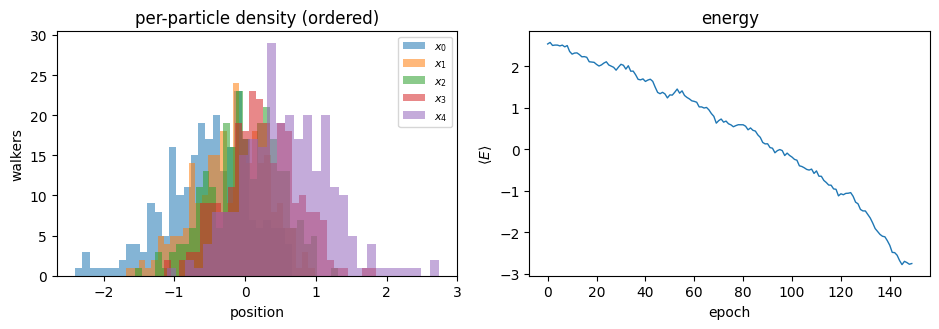

In [4]:
positions = np.asarray(result.final_positions)
gaps = np.diff(positions, axis=-1)

print(f"chains: {positions.shape[0]}, particles: {positions.shape[1]}")
print(f"all chains still ordered: {bool(np.all(gaps >= 0))}")
print(f"smallest gap seen:        {gaps.min():.3e}")

fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.4))
for p in range(n_particles):
    ax[0].hist(positions[:, p], bins=30, alpha=0.55, label=f"$x_{p}$")
ax[0].set(xlabel="position", ylabel="walkers", title="per-particle density (ordered)")
ax[0].legend(fontsize=8)

ax[1].plot(result.history.get("energy"), lw=1)
ax[1].set(xlabel="epoch", ylabel=r"$\langle E \rangle$", title="energy")
fig.tight_layout()

The per-particle densities are cleanly stacked left to right, which is what the
ordered sector looks like: particle *k* is the *k*-th smallest coordinate, so each one
occupies its own band.

## A caveat about this particular physics

`jastrow=None` above is a placeholder — there is no impenetrability term in the
wavefunction yet, only the sampler constraint. Without a node at coincidence, `psi`
does not vanish where `x_i = x_j`, so on the wedge the Hamiltonian is not self-adjoint
on that domain and the variational energy has **no lower bound**. Two symptoms:

- the energy sits below the bosonic `E_0 = 2.5` rather than above it;
- at the more natural `adam(3e-3)` it runs away to `E ~ -29` within 40 epochs.

That is a statement about the incomplete ansatz, not about the sampler — which is why
this notebook uses a small learning rate and checks ordering rather than energy. The
impenetrability term goes where `jastrow=None` is.

## Other constraints, same hook

In [5]:
@dataclass(frozen=True)
class BoxConfined(Metropolis):
    """Reflect walkers at hard walls at 0 and L (not a periodic wrap)."""
    L: float = 1.0

    def constrain(self, x):
        y = jnp.abs(jnp.mod(x, 2 * self.L))
        return jnp.where(y > self.L, 2 * self.L - y, y)

sampler = BoxConfined(L=3.0)
probe = jnp.array([-0.5, 1.0, 3.4, 7.2])
print("raw:        ", np.asarray(probe))
print("constrained:", np.asarray(sampler.constrain(probe)), " (all within [0, 3])")

raw:         [-0.5  1.   3.4  7.2]
constrained: [0.5       1.        2.6       1.1999998]  (all within [0, 3])


Same pattern for any restriction you can write as a projection: a fixed-node surface,
a hard-wall box, a spin sector. If a constraint cannot be written that way, override
`step` instead — but check the symmetry argument first.